In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hiranthikulathunga/wednesday-workinghours-pcap-iscx/Wednesday-workingHours.pcap_ISCX.csv


# Setup & Imports

In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix
from sklearn.model_selection import train_test_split

RANDOM_SEED = 123
#Models

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score,roc_auc_score,accuracy_score
import plotly.express as px


# Load data

In [3]:
df = pd.read_csv('/kaggle/input/datasets/hiranthikulathunga/wednesday-workinghours-pcap-iscx/Wednesday-workingHours.pcap_ISCX.csv')

In [4]:
df.columns


Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

**Remove all the extra spaces in the beginning and the end of column names**

In [5]:
new_col_dict = {}
for c in df.columns:
    new_col_dict[c] = c.strip()
df = df.rename(columns=new_col_dict)

# Clean Data

**filter data to the types of traffic used for the model. (DoS Slow Loris, Dos slowhttptest, Benign)**

In [6]:
df.loc[:, "Traffic_Group"] = np.where(
    df["Label"].isin(["DoS slowloris", "DoS Slowhttptest"]),
    "Slow Attack",
    "Other Traffic"
)

In [7]:
df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Traffic_Group
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Other Traffic
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Other Traffic
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Other Traffic
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Other Traffic
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Other Traffic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
692698,53,32215,4,2,112,152,28,28,28.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Other Traffic
692699,53,324,2,2,84,362,42,42,42.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Other Traffic
692700,58030,82,2,1,31,6,31,0,15.500000,21.920310,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Other Traffic
692701,53,1048635,6,2,192,256,32,32,32.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Other Traffic


In [8]:
print(df['Traffic_Group'].unique())

['Other Traffic' 'Slow Attack']


In [9]:
df["Traffic_Group"].value_counts()

Traffic_Group
Other Traffic    681408
Slow Attack       11295
Name: count, dtype: int64

show empty columns

In [10]:
nan_columns = df.columns[df.isna().sum()>0]
nan_columns

Index(['Flow Bytes/s'], dtype='object')

check for infinity

In [11]:
inf_columns = df.columns[df.isin([np.inf-np.inf]).any()]
inf_columns

Index(['Flow Bytes/s'], dtype='object')

Replace infinite values with NaN first

In [12]:
df[inf_columns] = df[inf_columns].replace([np.inf, -np.inf], np.nan)

Fill NaN with column mean

In [13]:
df[nan_columns] = df[nan_columns].fillna(df[nan_columns].mean())

check if it worked

In [14]:

df.isna().any().any()

np.False_

In [15]:
df['targetint'] = df['Traffic_Group'].map({'Other Traffic':0,'Slow Attack':1})
df['targetint'].value_counts()

targetint
0    681408
1     11295
Name: count, dtype: int64

# Exploratory Data Analysis 


Bar graph depicting the counts of Other Traffic and Slow Attack Traffic

<Axes: xlabel='Traffic_Group'>

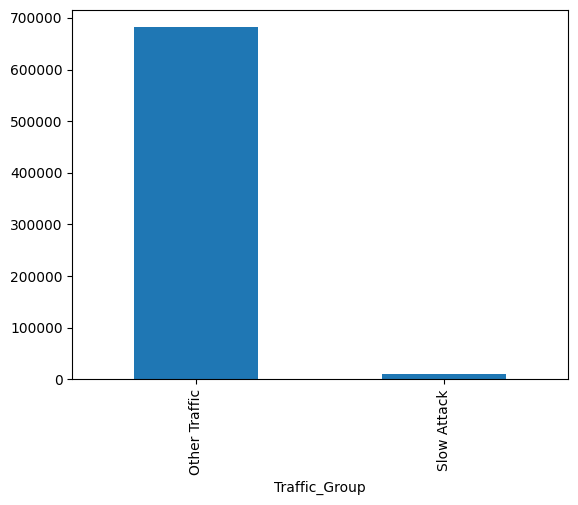

In [16]:
df['Traffic_Group'].value_counts().plot.bar()

In [17]:
# Compute correlations including target
features = ["Flow Duration", "Flow Packets/s", "Fwd Packet Length Mean", "Idle Mean", "targetint","Idle Max","Total Fwd Packets","Down/Up Ratio","SYN Flag Count","Fwd Packet Length Std","Flow IAT Mean","PSH Flag Count","ACK Flag Count","URG Flag Count","Packet Length Mean"]
corr_df = df[features].corr(numeric_only=True)

print(corr_df["targetint"].sort_values(ascending=False))

targetint                 1.000000
Flow IAT Mean             0.170562
PSH Flag Count            0.170211
SYN Flag Count            0.128039
Flow Duration             0.087665
Idle Max                  0.049150
Fwd Packet Length Mean    0.039236
Idle Mean                 0.021252
URG Flag Count            0.003541
Total Fwd Packets        -0.000605
Fwd Packet Length Std    -0.019615
Flow Packets/s           -0.034549
ACK Flag Count           -0.035031
Down/Up Ratio            -0.064166
Packet Length Mean       -0.065485
Name: targetint, dtype: float64


In [18]:
fig = px.imshow(
    corr_df,
    text_auto=True,
    aspect="auto",
    color_continuous_scale="RdBu_r",
    origin="lower",
    title="Correlation Heatmap: Selected Features"
)
fig.show()

# Feature engineering

In [19]:
df['Fwd Packet Length Range'] = df['Fwd Packet Length Max'] - df['Fwd Packet Length Min']
df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Traffic_Group,targetint,Fwd Packet Length Range
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,0,0,0.0,0.0,0,0,BENIGN,Other Traffic,0,0
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,0,0,0.0,0.0,0,0,BENIGN,Other Traffic,0,79
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,0,0,0.0,0.0,0,0,BENIGN,Other Traffic,0,1575
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,0,0,0.0,0.0,0,0,BENIGN,Other Traffic,0,1313
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,0,0,0.0,0.0,0,0,BENIGN,Other Traffic,0,1575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
692698,53,32215,4,2,112,152,28,28,28.000000,0.000000,...,0,0,0.0,0.0,0,0,BENIGN,Other Traffic,0,0
692699,53,324,2,2,84,362,42,42,42.000000,0.000000,...,0,0,0.0,0.0,0,0,BENIGN,Other Traffic,0,0
692700,58030,82,2,1,31,6,31,0,15.500000,21.920310,...,0,0,0.0,0.0,0,0,BENIGN,Other Traffic,0,31
692701,53,1048635,6,2,192,256,32,32,32.000000,0.000000,...,0,0,0.0,0.0,0,0,BENIGN,Other Traffic,0,0


# Split data set
- train (70%)
- validation (20%)
- test (10%) - for testing purposes only.

Flow IAT Mean - slow attacks have relatively higher inter-arrival times

PSH Flag Count - subtle difference in push flags usage

SYN Flag Count - TCP handshake pattern difference

Flow Duration - slow attacks last longer

Idle Max - slow attacks may have longer idle periods

Fwd Packet Length Mean - small packet sizes in forward direction

In [20]:
# Separate features (X) and target (y)
feature_cols = ['Flow IAT Mean','PSH Flag Count','SYN Flag Count','Flow Duration','Idle Max','Fwd Packet Length Mean']
X = df[feature_cols]
y = df['targetint']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)

# Train model

**Traning the model using logistic regression and Random forest**

In [22]:
mdl_logreg = LogisticRegression(random_state=RANDOM_SEED,max_iter=1000).fit(X_train, y_train)
mdl_rf = RandomForestClassifier(random_state=RANDOM_SEED).fit(X_train, y_train)


# logistic regression

In [23]:
train_preds_logreg = mdl_logreg.predict(X_train)
test_preds_logreg =  mdl_logreg.predict(X_test)
train_probs_logreg = mdl_logreg.predict_proba(X_train)[:,1] #This gets the probabilty (the [:,1] gets the prob on the ones class (i.e. low and slow))
test_probs_logreg =  mdl_logreg.predict_proba(X_test)[:,1]


In [24]:
set(train_preds_logreg)


{np.int64(0)}

the model did not learn anything. the set only contains 0s.

**logistic regression - model failed to train**

In [25]:
print(f'Train f1:{f1_score(y_train,train_preds_logreg)}')
print(f'Train Accuracy:{accuracy_score(y_train,train_preds_logreg)}')
print(f'Train AUC:{roc_auc_score(y_train,train_probs_logreg)}') # AUC needs probabiltys not predicted bools
print(f'Train Confusion Matrix:{confusion_matrix(y_train,train_preds_logreg)}')

print(f'Test f1:{f1_score(y_test,test_preds_logreg)}')
print(f'Test Accuracy:{accuracy_score(y_test,test_preds_logreg)}')
print(f'Test AUC:{roc_auc_score(y_test,test_probs_logreg)}')# AUC needs probabiltys not predicted bools
print(f'Test Confusion Matrix:{confusion_matrix(y_test,test_preds_logreg)}')


Train f1:0.0
Train Accuracy:0.9836942987790573
Train AUC:0.4853322499525787
Train Confusion Matrix:[[545126      0]
 [  9036      0]]
Test f1:0.0
Test Accuracy:0.9836943576269841
Test AUC:0.4909810347615342
Test Confusion Matrix:[[136282      0]
 [  2259      0]]


# Random forest 

In [26]:
train_preds_rf = mdl_rf.predict(X_train)
test_preds_rf =  mdl_rf.predict(X_test)
train_probs_rf = mdl_rf.predict_proba(X_train)[:,1] #This gets the probabilty (the [:,1] gets the prob on the ones class (i.e. low and slow))
test_probs_rf =  mdl_rf.predict_proba(X_test)[:,1]

# Results

In [27]:
print(f'Train f1:{f1_score(y_train,train_preds_rf)}')
print(f'Train Accuracy:{accuracy_score(y_train,train_preds_rf)}')
print(f'Train AUC:{roc_auc_score(y_train,train_probs_rf)}') # AUC needs probabiltys not predicted bools
print(f'Train Confusion Matrix:{confusion_matrix(y_train,train_preds_rf)}')

print(f'Test f1:{f1_score(y_test,test_preds_rf)}')
print(f'Test Accuracy:{accuracy_score(y_test,test_preds_rf)}')
print(f'Test AUC:{roc_auc_score(y_test,test_probs_rf)}')# AUC needs probabiltys not predicted bools
print(f'Test Confusion Matrix:{confusion_matrix(y_test,test_preds_rf)}')

Train f1:0.9990038738240177
Train Accuracy:0.9999675185234642
Train AUC:0.9999969738670925
Train Confusion Matrix:[[545118      8]
 [    10   9026]]
Test f1:0.9731170850922017
Test Accuracy:0.9991266123385857
Test AUC:0.9963245007963626
Test Confusion Matrix:[[136230     52]
 [    69   2190]]


**what are the most useful features in the model**

In [28]:
# Get feature importance - builtin to model
feature_importance_df = pd.DataFrame({'feature': X_train.columns, 'Gini importance': mdl_rf.feature_importances_})
feature_importance_df = feature_importance_df.sort_values(by='Gini importance', ascending=False)
print(feature_importance_df)

                  feature  Gini importance
0           Flow IAT Mean         0.361431
5  Fwd Packet Length Mean         0.190083
3           Flow Duration         0.189901
4                Idle Max         0.126527
1          PSH Flag Count         0.087053
2          SYN Flag Count         0.045005
